# Actividad Guiada 3 de Algoritmos de Optimización
Nombre: David Villacorta Nicolás <br>
Link:   https://colab.research.google.com/drive/1kf8Gc0zAZayTDkIxJQVRUrkOCez4I7Y-?usp=sharing <br>
Github: https://github.com/davidvilla10/03MIAR-Algoritmos-de-Optimizacion
<br>


#Carga de librerias

In [ ]:
!pip install requests
!pip install tabulate>=0.9 networkx>=3.0
!pip install tsplib95 --no-deps
!pip install deprecated

In [ ]:
!pip install deprecated

#Carga de los datos del problema

In [ ]:

import urllib.request #Hacer llamadas http a paginas de la red
import tsplib95       #Modulo para las instancias del problema del TSP
import math           #Modulo de funciones matematicas. Se usa para exp
import random         #Para generar valores aleatorios


#Descargamos el fichero de datos(Matriz de distancias)
file = "swiss42.tsp" ;
#urllib.request.urlretrieve("https://raw.githubusercontent.com/mastqe/tsplib/refs/heads/master/swiss42.tsp", file + '.gz')
urllib.request.urlretrieve("https://raw.githubusercontent.com/mastqe/tsplib/refs/heads/master/swiss42.tsp", file  )
#!gzip -d swiss42.tsp.gz     #Descomprimir el fichero de datos

#Coordendas 51-city problem (Christofides/Eilon)
#file = "eil51.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/eil51.tsp.gz", file)

#Coordenadas - 48 capitals of the US (Padberg/Rinaldi)
#file = "att48.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/att48.tsp.gz", file)


#http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95
#Documentacion :
  # http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp95.pdf
  # https://tsplib95.readthedocs.io/en/stable/pages/usage.html
  # https://tsplib95.readthedocs.io/en/v0.6.1/modules.html
  # https://pypi.org/project/tsplib95/




('swiss42.tsp', <http.client.HTTPMessage at 0x79ed93abff50>)

In [ ]:
#Carga de datos y generación de objeto problem
###############################################################################
problem = tsplib95.load(file)

#Nodos
Nodos = list(problem.get_nodes())

#Aristas
Aristas = list(problem.get_edges())



In [ ]:
Nodos

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41]

In [ ]:
Aristas
# https://github.com/mastqe/tsplib/blob/master/swiss42.tsp

[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (0, 4),
 (0, 5),
 (0, 6),
 (0, 7),
 (0, 8),
 (0, 9),
 (0, 10),
 (0, 11),
 (0, 12),
 (0, 13),
 (0, 14),
 (0, 15),
 (0, 16),
 (0, 17),
 (0, 18),
 (0, 19),
 (0, 20),
 (0, 21),
 (0, 22),
 (0, 23),
 (0, 24),
 (0, 25),
 (0, 26),
 (0, 27),
 (0, 28),
 (0, 29),
 (0, 30),
 (0, 31),
 (0, 32),
 (0, 33),
 (0, 34),
 (0, 35),
 (0, 36),
 (0, 37),
 (0, 38),
 (0, 39),
 (0, 40),
 (0, 41),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (1, 5),
 (1, 6),
 (1, 7),
 (1, 8),
 (1, 9),
 (1, 10),
 (1, 11),
 (1, 12),
 (1, 13),
 (1, 14),
 (1, 15),
 (1, 16),
 (1, 17),
 (1, 18),
 (1, 19),
 (1, 20),
 (1, 21),
 (1, 22),
 (1, 23),
 (1, 24),
 (1, 25),
 (1, 26),
 (1, 27),
 (1, 28),
 (1, 29),
 (1, 30),
 (1, 31),
 (1, 32),
 (1, 33),
 (1, 34),
 (1, 35),
 (1, 36),
 (1, 37),
 (1, 38),
 (1, 39),
 (1, 40),
 (1, 41),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (2, 4),
 (2, 5),
 (2, 6),
 (2, 7),
 (2, 8),
 (2, 9),
 (2, 10),
 (2, 11),
 (2, 12),
 (2, 13),
 (2, 14),
 (2, 15),
 (2, 16),
 (2, 17),
 (2, 18),



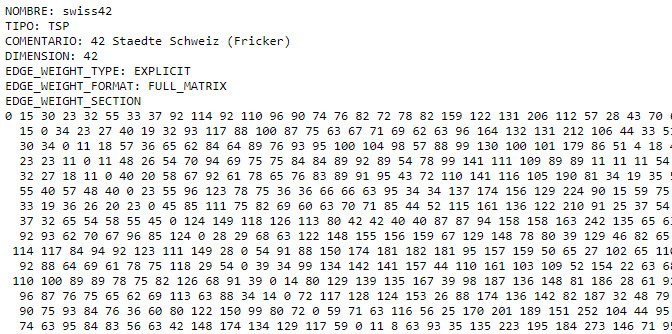

In [ ]:
#Probamos algunas funciones del objeto problem

#Distancia entre el nodo 3 y el 0
problem.get_weight(3, 0)

#Todas las funciones
#Documentación: https://tsplib95.readthedocs.io/en/v0.6.1/modules.html

#dir(problem)

23

#Funciones básicas


In [ ]:

#Funcionas basicas
###############################################################################

#Se genera una solucion aleatoria con comienzo en en el nodo 0
def crear_solucion(Nodos):
  solucion = [Nodos[0]]
  for n in Nodos[1:]:
    solucion = solucion + [random.choice(list(set(Nodos) - set({Nodos[0]}) - set(solucion)))]
  return solucion

#Devuelve la distancia entre dos nodos
def distancia(a,b, problem):
  return problem.get_weight(a,b)

#Devuelve la distancia total de una trayectoria/solucion
def distancia_total(solucion, problem):
  distancia_total = 0
  for i in range(len(solucion)-1):
    distancia_total += distancia(solucion[i] ,solucion[i+1] ,  problem) # Recorremos los nodos de la solución y vamos sumando las distancias de todas las aristas recorridas
  return distancia_total + distancia(solucion[len(solucion)-1] ,solucion[0], problem)

sol_temporal = crear_solucion(Nodos)


print(sol_temporal   )
print(distancia_total(sol_temporal, problem))

[0, 28, 34, 12, 3, 18, 31, 6, 41, 26, 21, 1, 5, 38, 36, 10, 17, 11, 33, 24, 4, 19, 29, 9, 16, 13, 25, 8, 30, 37, 23, 27, 7, 14, 39, 35, 40, 15, 20, 32, 22, 2]
5419


#BUSQUEDA ALEATORIA

In [ ]:
###############################################################################
# BUSQUEDA ALEATORIA
###############################################################################

def busqueda_aleatoria(problem, N):
  #N es el numero de iteraciones
  Nodos = list(problem.get_nodes())

  mejor_solucion = []
  #mejor_distancia = 10e100                         #Inicializamos con un valor alto
  mejor_distancia = float('inf')                    #Inicializamos con un valor alto

  for i in range(N):                                #Criterio de parada: repetir N veces pero podemos incluir otros
    solucion = crear_solucion(Nodos)                #Genera una solucion aleatoria
    distancia = distancia_total(solucion, problem)  #Calcula el valor objetivo(distancia total)

    if distancia < mejor_distancia:                 #Compara con la mejor obtenida hasta ahora
      mejor_solucion = solucion
      mejor_distancia = distancia


  print("Mejor solución:" , mejor_solucion)
  print("Distancia     :" , mejor_distancia)
  return mejor_solucion


#Busqueda aleatoria con 5000 iteraciones
solucion = busqueda_aleatoria(problem, 5000)

Mejor solución: [0, 7, 30, 38, 39, 34, 4, 19, 17, 16, 26, 3, 5, 6, 14, 32, 20, 35, 11, 21, 40, 22, 18, 27, 37, 33, 31, 10, 15, 23, 9, 24, 28, 2, 29, 41, 25, 12, 1, 8, 36, 13]
Distancia     : 3917


#BUSQUEDA LOCAL

In [ ]:
###############################################################################
# BUSQUEDA LOCAL(1 paso)
###############################################################################
def genera_vecina(solucion):
  #Generador de soluciones vecinas: 2-opt (intercambiar 2 nodos) Si hay N nodos se generan (N-1)x(N-2)/2 soluciones
  #Se puede modificar para aplicar otros generadores distintos que 2-opt. Podemos usar n-opt
  #print(solucion)
  mejor_solucion = []
  mejor_distancia = 10e100
  for i in range(1,len(solucion)-1):          #Recorremos todos los nodos en bucle doble para evaluar todos los intercambios 2-opt
    for j in range(i+1, len(solucion)):

      #Se genera una nueva solución intercambiando los dos nodos i,j:
      #  (usamos el operador + que para listas en python las concatena) : ej.: [1,2] + [3] = [1,2,3]
      vecina = solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]

      #Se evalua la nueva solución ...
      distancia_vecina = distancia_total(vecina, problem)

      #... para guardarla si mejora las anteriores
      if distancia_vecina <= mejor_distancia:
        mejor_distancia = distancia_vecina
        mejor_solucion = vecina
  return mejor_solucion


#solucion = [1, 47, 13, 41, 40, 19, 42, 44, 37, 5, 22, 28, 3, 2, 29, 21, 50, 34, 30, 9, 16, 11, 38, 49, 10, 39, 33, 45, 15, 24, 43, 26, 31, 36, 35, 20, 8, 7, 23, 48, 27, 12, 17, 4, 18, 25, 14, 6, 51, 46, 32]
print("Distancia Solucion Incial:" , distancia_total(solucion, problem))


nueva_solucion = genera_vecina(solucion)
print("Distancia Mejor Solucion Local:", distancia_total(nueva_solucion, problem))


Distancia Solucion Incial: 3917
Distancia Mejor Solucion Local: 3506


In [ ]:
#Busqueda Local(iteraciones):
#  - Sobre el operador de vecindad 2-opt(funcion genera_vecina)
#  - Sin criterio de parada, se para cuando no es posible mejorar.
def busqueda_local(solucion, problem):
  mejor_solucion = []

  #Generar una solucion inicial de referencia(aleatoria)
  #solucion_referencia = crear_solucion(Nodos)
  solucion_referencia = solucion
  mejor_distancia = distancia_total(solucion_referencia, problem)

  iteracion=0             #Un contador para saber las iteraciones que hacemos
  while(1):
    iteracion +=1         #Incrementamos el contador
    #print('#',iteracion)

    #Obtenemos la mejor vecina ...
    vecina = genera_vecina(solucion_referencia)

    #... y la evaluamos para ver si mejoramos respecto a lo encontrado hasta el momento
    distancia_vecina = distancia_total(vecina, problem)

    #Si no mejoramos hay que terminar. Hemos llegado a un minimo local(según nuestro operador de vencindad 2-opt)
    if distancia_vecina < mejor_distancia:
      #mejor_solucion = copy.deepcopy(vecina)   #Con copia profunda. Las copias en python son por referencia
      mejor_solucion = vecina                   #Guarda la mejor solución encontrada
      mejor_distancia = distancia_vecina

    else:
      print("En la iteracion ", iteracion, ", la mejor solución encontrada es:" , mejor_solucion)
      print("Distancia     :" , mejor_distancia)
      return mejor_solucion

    solucion_referencia = vecina


sol = busqueda_local(nueva_solucion, problem )

En la iteracion  32 , la mejor solución encontrada es: [0, 28, 30, 38, 22, 39, 29, 26, 13, 19, 5, 6, 4, 3, 27, 32, 20, 33, 34, 2, 12, 11, 18, 17, 36, 35, 31, 1, 8, 9, 21, 24, 40, 23, 41, 25, 10, 14, 16, 15, 37, 7]
Distancia     : 1923


## Propuesta de mejora para Búsqueda Local
Como propuesta de mejora, tras leer el pdf adjunto "Búsqueda por Entornos Variables para Planificación Logística, voy a implementar la búsqueda en entornos variables en su versión descendente (VND: Variable Neighbourhood Descent). La idea central es que un mínimo local respecto a un entorno no tiene por qué serlo respecto a otro, así que cambiamos sistemáticamente de vecindario para salir de óptimos locales “pobres” y alcanzar mínimos locales más robustos.

**¿Qué mejora respecto al 2-opt original?**

Antes, nuestra búsqueda local usaba un único entorno (intercambiar dos nodos). Eso hace que, en cuanto no encontramos mejora con ese movimiento, nos quedamos bloqueados en un mínimo local “según ese entorno”. Con VND, en cambio, definimos varias estructuras de entorno y las exploramos en orden. Cada vez que conseguimos una mejora, reiniciamos el recorrido de entornos desde el primero (k ← 1). Si no mejoramos en un entorno, pasamos al siguiente (k ← k+1). El algoritmo termina cuando ningún entorno consigue mejorar la solución actual; en ese momento hemos llegado a un mínimo local respecto a todos los entornos usados.

In [ ]:
###############################################################################
# BUSQUEDA LOCAL MEJORADA: VND (entornos variables) para TSP
###############################################################################
def genera_vecina_VND(solucion):
  """
  Funciones:
    1) swap (intercambiamos dos nodos y calculamos la nueva distancia total. Recorremos todas las combinaciones posibles y devolvemos la primera mejora encontrada.)
    2) 2-opt reversal (invertimos un segmento completo entre i y j en lugar de dos nodos sueltos cualesquiera.)
    3) relocate / insertion (sacar un nodo de la posición i y reinsertarlo en la posición j.)

  Estrategia: FIRST-IMPROVEMENT por velocidad. Si hay mejora, reiniciamos en el primer
  entorno; si no, pasamos al siguiente. Terminamos cuando ningún entorno mejora.
  """

  def mejora_por_swap(sol):
    base = distancia_total(sol, problem)
    n = len(sol)
    # i desde 1 para no tocar (si aplica) un origen fijo en sol[0]
    for i in range(1, n-1):
      for j in range(i+1, n):
        vec = sol[:i] + [sol[j]] + sol[i+1:j] + [sol[i]] + sol[j+1:]
        d = distancia_total(vec, problem)
        if d < base:
          return vec, d
    return sol, base

  def mejora_por_2opt_reversal(sol):
    base = distancia_total(sol, problem)
    n = len(sol)
    # invertimos el segmento (i..j)
    for i in range(1, n-2):
      for j in range(i+1, n-1):
        vec = sol[:i] + list(reversed(sol[i:j+1])) + sol[j+1:]
        d = distancia_total(vec, problem)
        if d < base:
          return vec, d
    return sol, base

  def mejora_por_relocate(sol):
    base = distancia_total(sol, problem)
    n = len(sol)
    # sacamos el nodo en i y lo insertamos en j (j recorre posiciones destino)
    for i in range(1, n-1):
      nodo = sol[i]
      resto = sol[:i] + sol[i+1:]
      for j in range(1, n-1):
        if j == i:
          continue
        vec = resto[:j] + [nodo] + resto[j:]
        d = distancia_total(vec, problem)
        if d < base:
          return vec, d
    return sol, base

  # --- VND: lista de entornos ---
  entornos = [mejora_por_2opt_reversal, mejora_por_relocate, mejora_por_swap]

  actual = solucion[:]
  dist_actual = distancia_total(actual, problem)

  k = 0
  while k < len(entornos):
    candidata, dist_cand = entornos[k](actual)
    if dist_cand < dist_actual:
      actual, dist_actual = candidata, dist_cand
      k = 0            # si mejora, reiniciamos en el primer entorno
    else:
      k += 1           # si no mejora, pasamos al siguiente entorno

  return actual

In [ ]:
###############################################################################
# BUSQUEDA LOCAL (VND): una llamada, porque VND ya incluye el criterio de parada
###############################################################################
def busqueda_local_VND(solucion, problem, verbose=True):
  # La solución inicial de referencia
  solucion_inicial = solucion[:]
  dist_inicial = distancia_total(solucion_inicial, problem)

  # VND ya hace mejoras sucesivas hasta que no hay mejora en ningún entorno
  mejor_solucion = genera_vecina_VND(solucion_inicial)
  mejor_distancia = distancia_total(mejor_solucion, problem)

  if verbose:
    print("Solución inicial:", solucion_inicial)
    print("Distancia inicial:", dist_inicial)
    print("Mejor solución encontrada (VND):", mejor_solucion)
    print("Distancia (VND):", mejor_distancia)

  return mejor_solucion


sol_vnd = busqueda_local_VND(nueva_solucion, problem)


Solución inicial: [0, 7, 30, 38, 39, 34, 4, 19, 17, 16, 26, 3, 5, 6, 14, 32, 20, 35, 11, 21, 40, 22, 18, 27, 37, 33, 31, 10, 8, 23, 9, 24, 28, 2, 29, 41, 25, 12, 1, 15, 36, 13]
Distancia inicial: 3506
Mejor solución encontrada (VND): [0, 32, 34, 33, 20, 35, 36, 31, 17, 37, 15, 16, 14, 7, 1, 6, 4, 3, 27, 2, 28, 29, 30, 38, 22, 39, 24, 40, 21, 9, 23, 41, 8, 10, 25, 11, 12, 18, 26, 13, 19, 5]
Distancia (VND): 1336


#SIMULATED ANNEALING


In [ ]:
###############################################################################
# SIMULATED ANNEALING
###############################################################################

#Generador de 1 solucion vecina 2-opt 100% aleatoria (intercambiar 2 nodos)
#Mejorable eligiendo otra forma de elegir una vecina.
def genera_vecina_aleatorio(solucion):

  #Se eligen dos nodos aleatoriamente
  i,j = sorted(random.sample( range(1,len(solucion)) , 2))

  #Devuelve una nueva solución pero intercambiando los dos nodos elegidos al azar
  return solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]


#Funcion de probabilidad para aceptar peores soluciones
def probabilidad(T,d):
  if random.random() <  math.exp( -1*d / T)  :
    return True
  else:
    return False

#Funcion de descenso de temperatura
def bajar_temperatura(T):
  return T*0.99

## Propuesta de mejora para Recocido Simulado
Como mejora del recocido simulado, vamos a sustituir el generador de vecinas puramente “2-opt por intercambio” (genera_vecina_aleatorio) por una versión más rica en movimientos, llamada **genera_vecina_mejorada()**. La motivación es que, en recocido simulado, la calidad de la exploración depende muchísimo del vecindario: si siempre hacemos el mismo tipo de cambio (swap), el algoritmo tiende a recorrer una zona pequeña del espacio de soluciones y le cuesta escapar de ciertos mínimos locales. En nuestra nueva función elegimos el movimiento en función de un número aleatorio r, y depende de lo que salga elegimos un movimiento u otro.

In [ ]:
###############################################################################
# SIMULATED ANNEALING - Generador de vecina mejorado
###############################################################################
def genera_vecina_mejorada(solucion):
  """
  Funciones (tipos de movimientos):
    - swap: intercambio de dos nodos (como el original que teníamos)
    - 2-opt reversal: invertimos un segmento completo (suele eliminar cruces)
    - relocate: sacamos un nodo de una posición i y lo reinsertamos en una posición j

  Idea: en recocido simulado nos interesa explorar bien el espacio, y combinar operadores suele dar
  mejores resultados que usar solo swap entre dos nodos.
  """
  n = len(solucion)

  # Elegimos el tipo de movimiento con pesos aleatorios
  r = random.random()
  if r < 0.25:
    # ---- SWAP ----
    i, j = sorted(random.sample(range(1, n), 2))
    return solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]

  elif r < 0.75:
    # ---- 2-OPT REVERSAL ----
    # Elegimos extremos del segmento y lo invertimos
    i, j = sorted(random.sample(range(1, n), 2))
    # Evitamos segmentos demasiado cortos de forma suave
    if j - i < 2 and n > 6:
      j = min(n-1, i + 2)
    return solucion[:i] + list(reversed(solucion[i:j+1])) + solucion[j+1:]

  else:
    # ---- RELOCATE / INSERTION ----
    i = random.choice(range(1, n))   # nodo a mover
    nodo = solucion[i]
    resto = solucion[:i] + solucion[i+1:]
    j = random.choice(range(1, n))   # nueva posición (en la lista "resto" el largo sigue siendo n-1)
    return resto[:j] + [nodo] + resto[j:]


In [ ]:
###############################################################################
# SIMULATED ANNEALING (con generador de vecinas parametrizable)
###############################################################################
def recocido_simulado(problem, TEMPERATURA, genera_vecina):
  #problem = datos del problema
  #T = Temperatura
  #genera_vecina = función generadora de vecinas (aleatoria o mejorada)

  solucion_referencia = crear_solucion(Nodos)
  distancia_referencia = distancia_total(solucion_referencia, problem)

  mejor_solucion = []             #x* del seudocodigo
  mejor_distancia = 10e100        #F* del seudocodigo


  N=0
  while TEMPERATURA > .0001:
    N+=1
    #Genera una solución vecina
    vecina = genera_vecina(solucion_referencia)

    #Calcula su valor(distancia)
    distancia_vecina = distancia_total(vecina, problem)

    #Si es la mejor solución de todas se guarda(siempre!!!)
    if distancia_vecina < mejor_distancia:
        mejor_solucion = vecina
        mejor_distancia = distancia_vecina

    #Si la nueva vecina es mejor se cambia
    #Si es peor se cambia según una probabilidad que depende de T y delta(distancia_referencia - distancia_vecina)
    if distancia_vecina < distancia_referencia or probabilidad(TEMPERATURA, abs(distancia_referencia - distancia_vecina) ) :
      #solucion_referencia = copy.deepcopy(vecina)
      solucion_referencia = vecina
      distancia_referencia = distancia_vecina

    #Bajamos la temperatura
    TEMPERATURA = bajar_temperatura(TEMPERATURA)


  return mejor_solucion, mejor_distancia




In [ ]:
###############################################################################
# COMPARACIÓN FINAL: SA con vecina aleatoria vs SA con vecina mejorada
###############################################################################

# Ejecutar con vecina aleatoria (original)
sol_aleatoria, distancia_aleatoria = recocido_simulado(problem, 10000000, genera_vecina_aleatorio)

# Ejecutar con vecina mejorada (nueva)
sol_mejorada, distancia_mejorada  = recocido_simulado(problem, 10000000, genera_vecina_mejorada)

print("=== RESULTADO Recocido Simulado (vecina_aleatoria) ===")
print("Solución:", sol_aleatoria)
print("Distancia:", distancia_aleatoria)

print("\n=== RESULTADO Recocido Simulado (vecina_mejorada) ===")
print("Solución:", sol_mejorada)
print("Distancia:", distancia_mejorada)

=== RESULTADO Recocido Simulado (vecina_aleatoria) ===
Solución: [0, 39, 21, 40, 24, 35, 36, 31, 37, 28, 30, 29, 27, 2, 8, 9, 22, 38, 33, 20, 34, 32, 17, 7, 5, 26, 18, 11, 12, 6, 3, 4, 25, 10, 23, 41, 13, 16, 15, 14, 19, 1]
Distancia: 2183

=== RESULTADO Recocido Simulado (vecina_mejorada) ===
Solución: [0, 3, 14, 16, 15, 37, 17, 31, 35, 36, 33, 20, 34, 28, 2, 32, 30, 38, 22, 29, 10, 41, 23, 40, 24, 21, 39, 9, 8, 18, 12, 11, 25, 27, 4, 6, 26, 5, 13, 19, 7, 1]
Distancia: 1684


#Representación en un grafo a partir de la matriz de distancias( Optimización de posiciones usando escalado multidimensional (MDS)



Multidimensional scaling problem(MDS):   https://en.wikipedia.org/wiki/Multidimensional_scaling

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import MDS  # Multidimensional Scaling o Escalado Multidimensional

def plot_tsp_solution(distance_matrix, tsp_solution):
    """
    Dibuja el grafo de un TSP con las posiciones calculadas mediante MDS y muestra
    solo las aristas correspondientes a la solución del TSP.

    :param distance_matrix: np.ndarray, matriz de distancias entre nodos
    :param tsp_solution: list, lista de nodos en el orden de la solución del TSP
    """
    # Crear el grafo completo
    G = nx.Graph()
    num_nodes = len(distance_matrix)
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            G.add_edge(i, j, weight=distance_matrix[i][j])

    # Usar MDS para calcular posiciones de los nodos
    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
    positions = mds.fit_transform(distance_matrix)

    # Convertir las posiciones en un diccionario para networkx
    pos = {i: positions[i] for i in range(num_nodes)}

    # Crear un subgrafo con las aristas del camino TSP
    TSP_G = nx.Graph()
    for i in range(len(tsp_solution) - 1):
        u = tsp_solution[i]
        v = tsp_solution[i + 1]
        TSP_G.add_edge(u, v, weight=distance_matrix[u][v])

    # Dibujar el grafo
    plt.figure(figsize=(8, 6))

    # Dibujar nodos
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)

    # Dibujar las aristas del camino TSP
    nx.draw_networkx_edges(TSP_G, pos, edge_color='red', width=2)

    # Añadir etiquetas a los nodos y pesos de las aristas
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    edge_labels = nx.get_edge_attributes(TSP_G, 'weight')
    nx.draw_networkx_edge_labels(TSP_G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Grafo TSP con solución específica")
    plt.show()


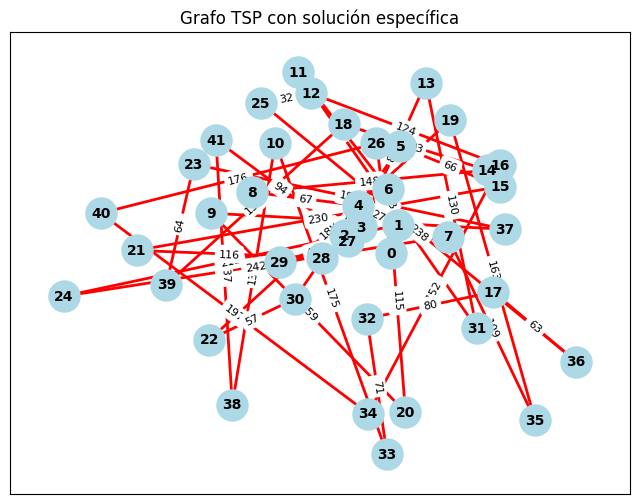

In [ ]:
plot_tsp_solution(problem.edge_weights, crear_solucion(Nodos))

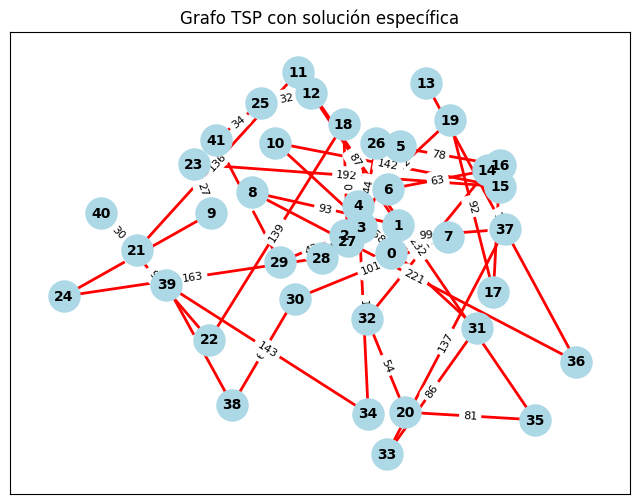

In [ ]:
plot_tsp_solution(problem.edge_weights, solucion)